In [73]:
!pip install gdown -q
!pip install pandas numpy matplotlib seaborn scipy

import gdown 

gdown.download(
    'https://drive.google.com/uc?id=1f1Rrn9xbWp7xDgcYYUSxuHHltQzqXUXK',
    'train_vitals.csv', quiet=False
)

gdown.download(
    'https://drive.google.com/uc?id=1QNxbxxt4LhuR3-BmdghaUz-XQ0tQhSC3',
    'test_vitals.csv', quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1f1Rrn9xbWp7xDgcYYUSxuHHltQzqXUXK
To: /kaggle/working/train_vitals.csv
100%|██████████| 3.99M/3.99M [00:00<00:00, 232MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QNxbxxt4LhuR3-BmdghaUz-XQ0tQhSC3
To: /kaggle/working/test_vitals.csv
100%|██████████| 17.8M/17.8M [00:00<00:00, 154MB/s]


'test_vitals.csv'

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import iqr, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

SEED = 42
np.random.seed(SEED)

C_TRAIN  = '#1D9E75'
C_TEST   = '#534AB7'
C_ALERT  = '#D85A30'
C_MISS   = '#888780'
C_ACCENT = '#BA7517'

VITALS = ['HR', 'MBP', 'SpO2', 'Temp']

# Clinical normal ranges from problem statement
CLINICAL_NORMAL = {
    'HR'  : (40,  150),
    'MBP' : (50,  120),
    'SpO2': (90,  100),
    'Temp': (35.0, 39.5),
}

In [75]:
df_train = pd.read_csv('/kaggle/working/train_vitals.csv')
df_test  = pd.read_csv('test_vitals.csv')

print("=== TRAIN ===")
print(f"Shape   : {df_train.shape}")
print(f"Columns : {df_train.columns.tolist()}")
print(f"Cases   : {df_train['case_id'].nunique()}")
print()
print(df_train.head(10))

print("\n=== TEST ===")
print(f"Shape   : {df_test.shape}")
print(f"Columns : {df_test.columns.tolist()}")
print(f"Cases   : {df_test['case_id'].nunique()}")
print()
print(df_test.head(10))

print("\n=== TRAIN dtypes ===")
print(df_train.dtypes)

=== TRAIN ===
Shape   : (122347, 6)
Columns : ['case_id', 'time_sec', 'HR', 'MBP', 'SpO2', 'Temp']
Cases   : 20

   case_id  time_sec       HR     MBP    SpO2  Temp
0      135         1 112.0000 -1.0000 97.0000   NaN
1      135         3 112.0000 -1.0000 97.0000   NaN
2      135         5 111.0000 -1.0000 97.0000   NaN
3      135         7 111.0000 -2.0000 97.0000   NaN
4      135         9 112.0000 -2.0000 97.0000   NaN
5      135        11 112.0000 -2.0000 98.0000   NaN
6      135        13 113.0000 -2.0000 98.0000   NaN
7      135        15 113.0000 -1.0000 98.0000   NaN
8      135        17 113.0000 -1.0000 98.0000   NaN
9      135        19 113.0000 -1.0000 98.0000   NaN

=== TEST ===
Shape   : (550583, 6)
Columns : ['case_id', 'time_sec', 'HR', 'MBP', 'SpO2', 'Temp']
Cases   : 75

   case_id  time_sec      HR     MBP    SpO2  Temp
0        1         1 88.0000 -8.0000 96.0000   NaN
1        1         3 87.0000 -8.0000 96.0000   NaN
2        1         5 88.0000 -8.0000 97.0000   Na

In [4]:
train_cases = set(df_train['case_id'].unique())
test_cases  = set(df_test['case_id'].unique())

print(f"Train case_ids : min={min(train_cases)}  max={max(train_cases)}  n={len(train_cases)}")
print(f"Test  case_ids : min={min(test_cases)}   max={max(test_cases)}   n={len(test_cases)}")
print(f"Overlap        : {train_cases & test_cases}")

# Time step regularity — expected 2 sec intervals
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    sample_case = sorted(df['case_id'].unique())[0]
    sample = df[df['case_id'] == sample_case].sort_values('time_sec')
    diffs  = sample['time_sec'].diff().dropna()
    print(f"\n[{label}] Time step value_counts (case {sample_case}):")
    print(diffs.value_counts().head(8))

# Duplicates
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    dups = df.duplicated(subset=['case_id', 'time_sec']).sum()
    print(f"\n[{label}] Duplicate (case_id, time_sec) pairs: {dups}")

Train case_ids : min=135  max=163  n=20
Test  case_ids : min=1   max=132   n=75
Overlap        : set()

[TRAIN] Time step value_counts (case 135):
time_sec
2.0000     5619
3.0000        2
6.0000        2
28.0000       2
10.0000       2
1.0000        1
26.0000       1
74.0000       1
Name: count, dtype: int64

[TEST] Time step value_counts (case 1):
time_sec
2.0000     5419
3.0000        8
1.0000        7
4.0000        3
14.0000       2
Name: count, dtype: int64

[TRAIN] Duplicate (case_id, time_sec) pairs: 0

[TEST] Duplicate (case_id, time_sec) pairs: 0



=== TRAIN case stats ===
          n_rows  duration_sec
count    20.0000       20.0000
mean   6117.3500    12440.3000
std    2689.2246     5386.8405
min    2100.0000     4233.0000
25%    4338.7500     8993.7500
50%    5703.5000    11905.5000
75%    7527.0000    15202.0000
max   13295.0000    26695.0000

=== TEST case stats ===
          n_rows  duration_sec
count    75.0000       75.0000
mean   7341.1067    15050.3733
std    3422.1695     7056.5079
min    1670.0000     3376.0000
25%    4983.0000    10184.0000
50%    6778.0000    13685.0000
75%    9182.5000    18940.0000
max   18331.0000    36911.0000


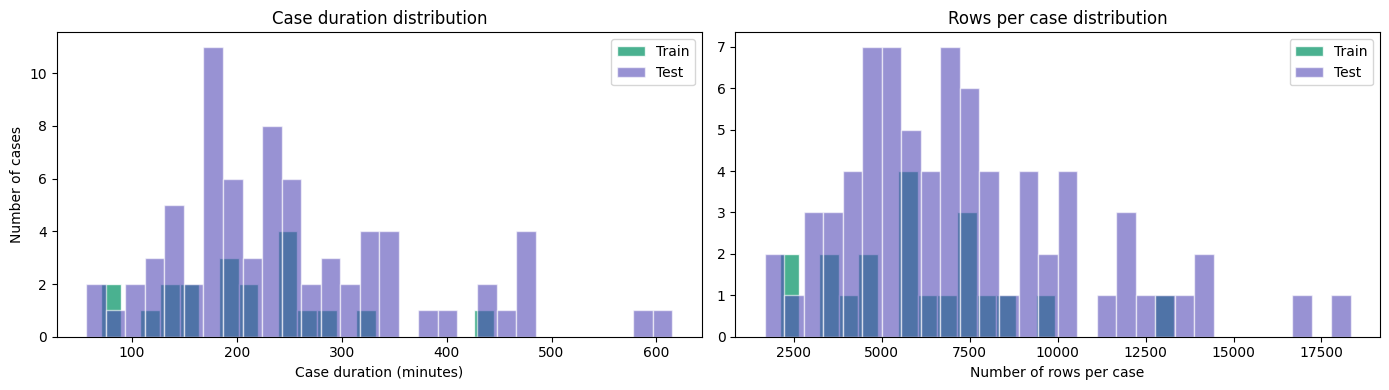

In [5]:
def case_stats(df, label):
    stats_df = df.groupby('case_id').agg(
        n_rows       = ('time_sec', 'count'),
        duration_sec = ('time_sec', lambda x: x.max() - x.min()),
        t_start      = ('time_sec', 'min'),
        t_end        = ('time_sec', 'max'),
    ).reset_index()
    print(f"\n=== {label} case stats ===")
    print(stats_df[['n_rows', 'duration_sec']].describe())
    return stats_df

train_case_stats = case_stats(df_train, 'TRAIN')
test_case_stats  = case_stats(df_test,  'TEST')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_case_stats['duration_sec'] / 60, bins=20,
             color=C_TRAIN, edgecolor='white', alpha=0.8, label='Train')
axes[0].hist(test_case_stats['duration_sec'] / 60, bins=30,
             color=C_TEST, edgecolor='white', alpha=0.6, label='Test')
axes[0].set_xlabel('Case duration (minutes)')
axes[0].set_ylabel('Number of cases')
axes[0].set_title('Case duration distribution')
axes[0].legend()

axes[1].hist(train_case_stats['n_rows'], bins=20,
             color=C_TRAIN, edgecolor='white', alpha=0.8, label='Train')
axes[1].hist(test_case_stats['n_rows'], bins=30,
             color=C_TEST, edgecolor='white', alpha=0.6, label='Test')
axes[1].set_xlabel('Number of rows per case')
axes[1].set_title('Rows per case distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_case_durations.png', dpi=150, bbox_inches='tight')
plt.show()


=== TRAIN — Missingness ===
  HR     :        0 / 122,347  (0.00%)
  MBP    :        0 / 122,347  (0.00%)
  SpO2   :        0 / 122,347  (0.00%)
  Temp   :   69,954 / 122,347  (57.18%)

=== TEST — Missingness ===
  HR     :        0 / 550,583  (0.00%)
  MBP    :        0 / 550,583  (0.00%)
  SpO2   :        0 / 550,583  (0.00%)
  Temp   :  290,273 / 550,583  (52.72%)

[TRAIN] Per-patient Temp missing rate:
count   20.0000
mean     0.5679
std      0.2491
min      0.1375
25%      0.3970
50%      0.5546
75%      0.7957
max      0.9647
Name: temp_miss_rate, dtype: float64
  Patients with 100% Temp missing : 0
  Patients with 0%   Temp missing : 0

[TEST] Per-patient Temp missing rate:
count   75.0000
mean     0.5674
std      0.3032
min      0.0322
25%      0.3161
50%      0.5311
75%      0.8738
max      1.0000
Name: temp_miss_rate, dtype: float64
  Patients with 100% Temp missing : 7
  Patients with 0%   Temp missing : 0

[TRAIN] Temp presence by time decile (normalised within case):
time

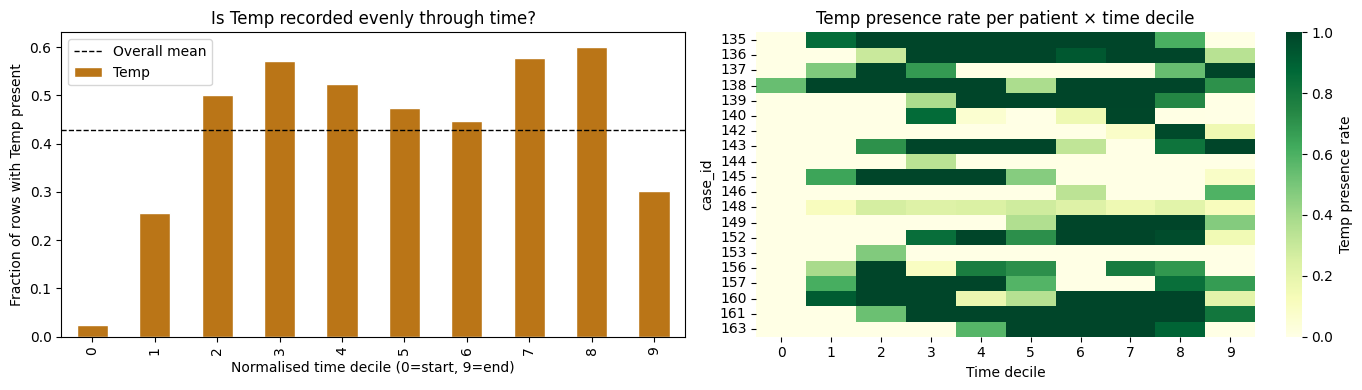

In [6]:
def missing_summary(df, label):
    print(f"\n=== {label} — Missingness ===")
    total = len(df)
    for col in VITALS:
        n    = df[col].isna().sum()
        pct  = n / total * 100
        print(f"  {col:6s} : {n:>8,} / {total:,}  ({pct:.2f}%)")

missing_summary(df_train, 'TRAIN')
missing_summary(df_test,  'TEST')

# Per-patient Temp missingness — the main concern
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    temp_by_patient = df.groupby('case_id')['Temp'].apply(
        lambda x: x.isna().mean()
    ).rename('temp_miss_rate')
    print(f"\n[{label}] Per-patient Temp missing rate:")
    print(temp_by_patient.describe())
    n_all_missing = (temp_by_patient == 1.0).sum()
    n_none_missing = (temp_by_patient == 0.0).sum()
    print(f"  Patients with 100% Temp missing : {n_all_missing}")
    print(f"  Patients with 0%   Temp missing : {n_none_missing}")

# Is Temp missingness structured in time?
# Look at where in the timeline Temp is recorded vs missing
print("\n[TRAIN] Temp presence by time decile (normalised within case):")
df_train['time_norm'] = df_train.groupby('case_id')['time_sec'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)
df_train['time_decile'] = pd.cut(df_train['time_norm'], bins=10, labels=False)
temp_presence_by_decile = df_train.groupby('time_decile')['Temp'].apply(
    lambda x: x.notna().mean()
)
print(temp_presence_by_decile.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

temp_presence_by_decile.plot(kind='bar', ax=axes[0], color=C_ACCENT, edgecolor='white')
axes[0].set_xlabel('Normalised time decile (0=start, 9=end)')
axes[0].set_ylabel('Fraction of rows with Temp present')
axes[0].set_title('Is Temp recorded evenly through time?')
axes[0].axhline(df_train['Temp'].notna().mean(), color='black',
                linestyle='--', linewidth=1, label='Overall mean')
axes[0].legend()

# Missingness heatmap across patients
temp_miss_matrix = df_train.pivot_table(
    index='case_id', columns='time_decile',
    values='Temp', aggfunc=lambda x: x.notna().mean()
)
sns.heatmap(temp_miss_matrix, ax=axes[1], cmap='YlGn',
            cbar_kws={'label': 'Temp presence rate'})
axes[1].set_title('Temp presence rate per patient × time decile')
axes[1].set_xlabel('Time decile')
axes[1].set_ylabel('case_id')

plt.tight_layout()
df_train.drop(columns=['time_norm', 'time_decile'], inplace=True)
plt.savefig('eda_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

=== TRAIN — Raw descriptive statistics ===
               HR         MBP        SpO2       Temp
count 122347.0000 122347.0000 122347.0000 52393.0000
mean      69.2446     80.1948     99.6753    35.7053
std       14.2198     30.4449      1.1329     2.2724
min        0.0000    -61.0000     63.0000     0.5000
1%        45.0000    -10.0000     95.0000    20.1000
5%        50.0000     29.0000     98.0000    34.7000
25%       60.0000     71.0000    100.0000    35.7000
50%       67.0000     81.0000    100.0000    36.0000
75%       76.0000     91.0000    100.0000    36.4000
95%       97.0000    112.0000    100.0000    36.8000
99%      109.0000    214.0000    100.0000    37.1000
max      306.0000    331.0000    100.0000    37.8000

=== TEST — Raw descriptive statistics ===
               HR         MBP        SpO2        Temp
count 550583.0000 550583.0000 550583.0000 260310.0000
mean      73.4614     78.6891     99.5535     35.2334
std       14.3629     27.2730      1.3894      2.7002
min      

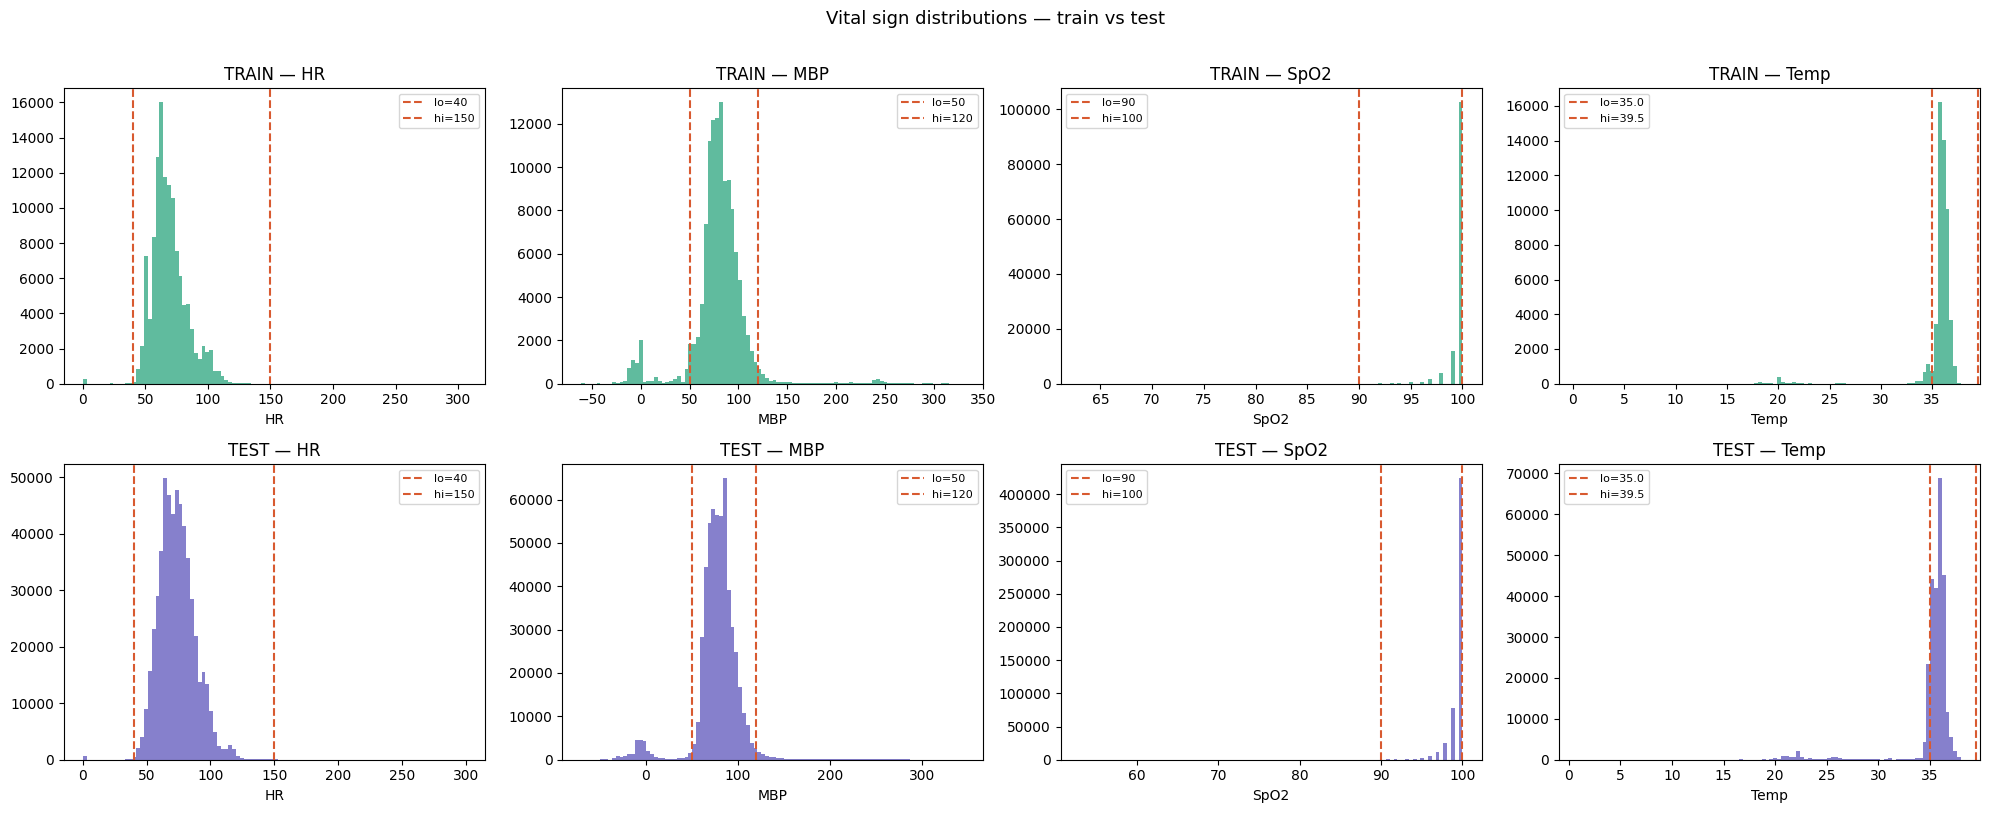

In [7]:
print("=== TRAIN — Raw descriptive statistics ===")
print(df_train[VITALS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

print("\n=== TEST — Raw descriptive statistics ===")
print(df_test[VITALS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# Count values outside clinical normal ranges
print("\n=== Values outside clinical normal ranges ===")
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n  [{label}]")
    for vital, (lo, hi) in CLINICAL_NORMAL.items():
        n_valid  = df[vital].notna().sum()
        n_below  = (df[vital] < lo).sum()
        n_above  = (df[vital] > hi).sum()
        n_neg    = (df[vital] < 0).sum()
        print(f"    {vital:6s} : below {lo:>6} = {n_below:>7,} | "
              f"above {hi:>6} = {n_above:>7,} | "
              f"negative = {n_neg:>6,} | "
              f"valid n = {n_valid:,}")

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, vital in enumerate(VITALS):
    lo, hi = CLINICAL_NORMAL[vital]

    # Row 0: train distribution
    ax = axes[0][i]
    data = df_train[vital].dropna()
    ax.hist(data, bins=100, color=C_TRAIN, alpha=0.7, edgecolor='none')
    ax.axvline(lo, color=C_ALERT, linestyle='--', linewidth=1.5, label=f'lo={lo}')
    ax.axvline(hi, color=C_ALERT, linestyle='--', linewidth=1.5, label=f'hi={hi}')
    ax.set_title(f'TRAIN — {vital}')
    ax.set_xlabel(vital)
    ax.legend(fontsize=8)

    # Row 1: test distribution
    ax = axes[1][i]
    data = df_test[vital].dropna()
    ax.hist(data, bins=100, color=C_TEST, alpha=0.7, edgecolor='none')
    ax.axvline(lo, color=C_ALERT, linestyle='--', linewidth=1.5, label=f'lo={lo}')
    ax.axvline(hi, color=C_ALERT, linestyle='--', linewidth=1.5, label=f'hi={hi}')
    ax.set_title(f'TEST — {vital}')
    ax.set_xlabel(vital)
    ax.legend(fontsize=8)

plt.suptitle('Vital sign distributions — train vs test', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Goal: distinguish true physiological extremes from sensor faults
# Strategy: look at value distribution near boundaries + duration of extreme readings

print("=== Negative value analysis ===")
for vital in VITALS:
    neg = df_train[df_train[vital] < 0][vital]
    if len(neg) > 0:
        print(f"\n  {vital} — {len(neg):,} negative values")
        print(f"    range  : {neg.min():.2f} → {neg.max():.2f}")
        print(f"    median : {neg.median():.2f}")
        # How long do negative runs last? (sustained = real, single point = artefact)
        for case_id, grp in df_train[df_train[vital] < 0].groupby('case_id'):
            pass  # count will be aggregated below
        n_cases = df_train[df_train[vital] < 0]['case_id'].nunique()
        print(f"    appears in {n_cases} cases")

# For MBP specifically — look at distribution around 0
print("\n=== MBP value distribution near 0 ===")
mbp_near_zero = df_train[df_train['MBP'].between(-30, 30)]['MBP']
print(mbp_near_zero.value_counts().sort_index().head(30))

# SpO2 ceiling effect — 100% is the sensor max
spo2_100_pct = (df_train['SpO2'] == 100).mean()
print(f"\n=== SpO2 = 100 frequency ===")
print(f"  {spo2_100_pct:.2%} of all SpO2 readings are exactly 100")
print("  → sensor clips at 100; these are NOT anomalies, they are normals at ceiling")

# HR = 0 — sensor off or asystole?
hr_zero = (df_train['HR'] == 0).sum()
print(f"\n=== HR = 0 count: {hr_zero} ===")
print("  → if brief single points: sensor artefact. If sustained: clinical emergency.")

# Determine sustained vs transient extremes for MBP < 0
print("\n=== MBP < 0 run lengths (consecutive negative readings per case) ===")
neg_runs = []
for case_id, grp in df_train.groupby('case_id'):
    arr = grp.sort_values('time_sec')['MBP'].values
    run = 0
    for v in arr:
        if v < 0:
            run += 1
        else:
            if run > 0:
                neg_runs.append(run)
            run = 0
    if run > 0:
        neg_runs.append(run)

if neg_runs:
    print(f"  Total negative MBP runs : {len(neg_runs)}")
    print(f"  Median run length       : {np.median(neg_runs):.1f} timestamps")
    print(f"  Max run length          : {max(neg_runs)} timestamps")
    print(f"  Single-point runs       : {sum(r==1 for r in neg_runs)} ({sum(r==1 for r in neg_runs)/len(neg_runs):.1%})")
    print("  → Mostly single-point = sensor offset artefact → treat as NaN")
    print("  → Sustained runs = possible real clinical reading → keep + flag")

=== Negative value analysis ===

  MBP — 4,220 negative values
    range  : -61.00 → -1.00
    median : -7.00
    appears in 20 cases

=== MBP value distribution near 0 ===
MBP
-30.0000      2
-29.0000      1
-27.0000     34
-26.0000     26
-25.0000     19
-24.0000      6
-23.0000      3
-20.0000     23
-19.0000     48
-18.0000     20
-17.0000     29
-16.0000     74
-15.0000     17
-14.0000     22
-13.0000    395
-12.0000    155
-11.0000    193
-10.0000    216
-9.0000     196
-8.0000     330
-7.0000     345
-6.0000     160
-5.0000     156
-4.0000     223
-3.0000     436
-2.0000     821
-1.0000     234
0.0000      517
1.0000      467
2.0000       36
Name: count, dtype: int64

=== SpO2 = 100 frequency ===
  83.79% of all SpO2 readings are exactly 100
  → sensor clips at 100; these are NOT anomalies, they are normals at ceiling

=== HR = 0 count: 247 ===
  → if brief single points: sensor artefact. If sustained: clinical emergency.

=== MBP < 0 run lengths (consecutive negative readings p

=== Between-patient variability (patient-level medians) ===
           HR     MBP     SpO2    Temp
count 20.0000 20.0000  20.0000 20.0000
mean  69.1000 79.6000  99.8000 35.9850
std   10.1613 10.6643   0.5231  0.5878
min   51.0000 55.0000  98.0000 34.3000
25%   63.5000 74.5000 100.0000 35.8500
50%   66.0000 80.5000 100.0000 36.0000
75%   71.0000 85.0000 100.0000 36.3250
max   98.0000 96.0000 100.0000 36.8000

=== Within-patient variability (patient-level std) ===
           HR     MBP    SpO2    Temp
count 20.0000 20.0000 20.0000 20.0000
mean   9.2929 28.7232  0.8849  1.2359
std    3.8362  9.1715  0.6818  2.2860
min    4.3053 17.8995  0.2635  0.0492
25%    6.7030 22.4138  0.3501  0.2489
50%    8.3792 27.6966  0.5254  0.4325
75%   10.6105 32.1508  1.3592  0.5970
max   19.5574 57.0817  2.4359  7.9320

=== Within/Between variance ratio ===
  HR     : within=9.293  between=10.161  ratio=0.915
  MBP    : within=28.723  between=10.664  ratio=2.693
  SpO2   : within=0.885  between=0.523  ratio

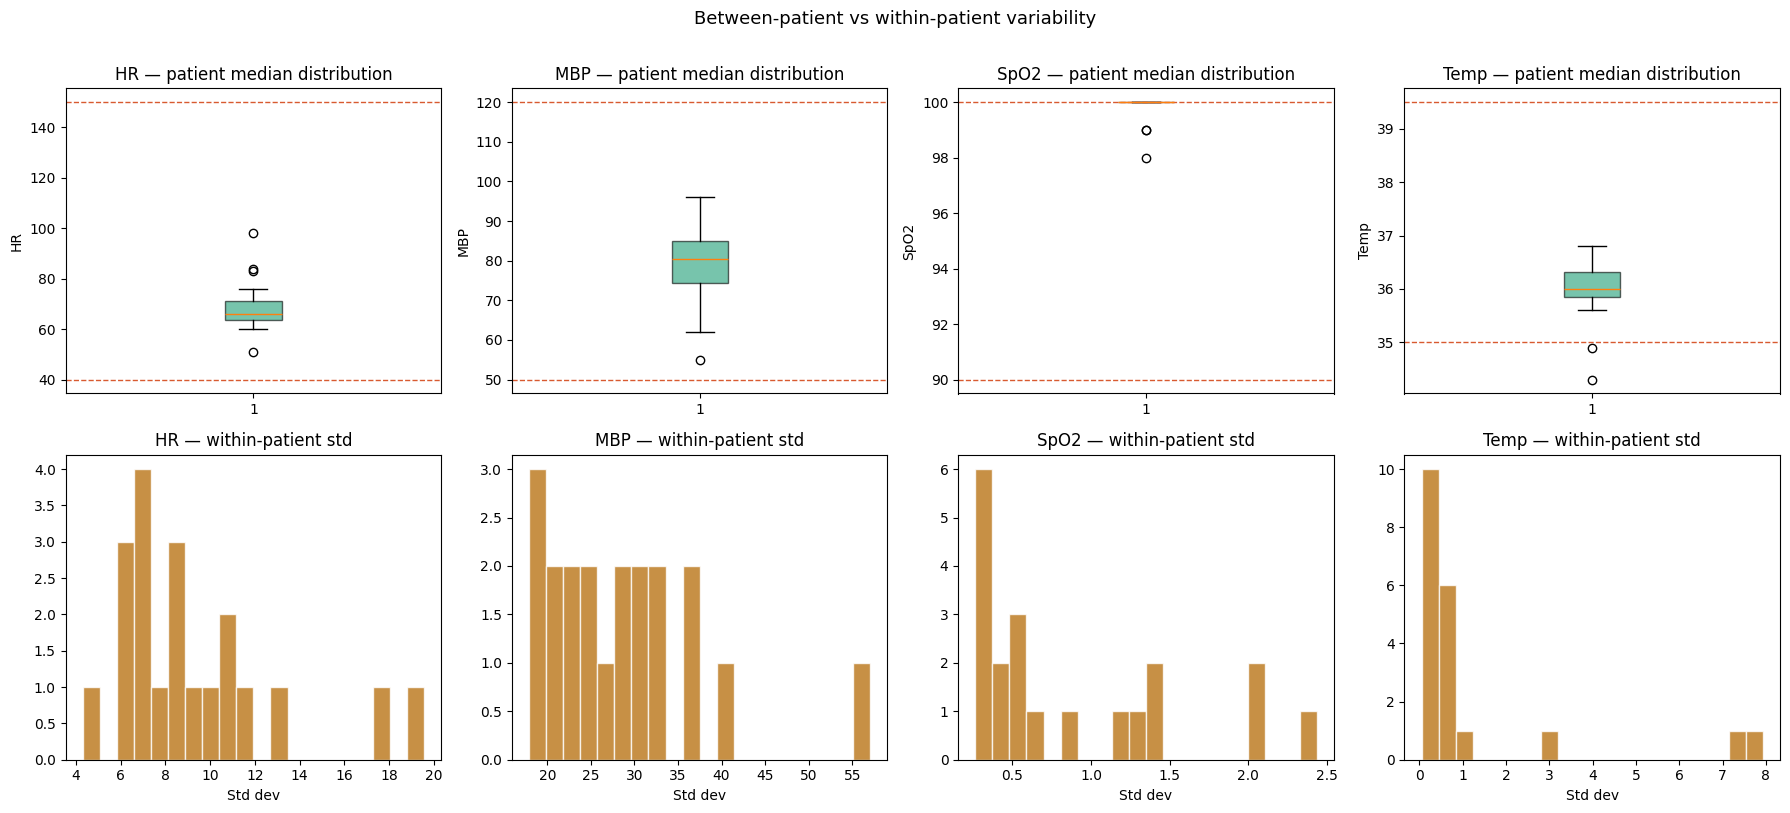

In [9]:
# Key insight: patients have different physiological baselines
# A HR of 90 is normal for one patient, high for another
# We need to understand within-patient variance vs between-patient variance

print("=== Between-patient variability (patient-level medians) ===")
patient_medians = df_train.groupby('case_id')[VITALS].median()
print(patient_medians.describe())

print("\n=== Within-patient variability (patient-level std) ===")
patient_stds = df_train.groupby('case_id')[VITALS].std()
print(patient_stds.describe())

# Ratio: within-patient std / between-patient std
# High ratio → per-patient normalisation important
print("\n=== Within/Between variance ratio ===")
within  = patient_stds.mean()
between = patient_medians.std()
for v in VITALS:
    print(f"  {v:6s} : within={within[v]:.3f}  between={between[v]:.3f}  "
          f"ratio={within[v]/between[v]:.3f}")
print("  → ratio > 0.5: per-patient normalisation is important")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, vital in enumerate(VITALS):
    lo, hi = CLINICAL_NORMAL[vital]

    # Row 0: box plot of patient medians
    ax = axes[0][i]
    ax.boxplot(patient_medians[vital].dropna(), vert=True,
               patch_artist=True,
               boxprops=dict(facecolor=C_TRAIN, alpha=0.6))
    ax.axhline(lo, color=C_ALERT, linestyle='--', linewidth=1)
    ax.axhline(hi, color=C_ALERT, linestyle='--', linewidth=1)
    ax.set_title(f'{vital} — patient median distribution')
    ax.set_ylabel(vital)

    # Row 1: within-patient std distribution
    ax = axes[1][i]
    ax.hist(patient_stds[vital].dropna(), bins=20,
            color=C_ACCENT, edgecolor='white', alpha=0.8)
    ax.set_title(f'{vital} — within-patient std')
    ax.set_xlabel('Std dev')

plt.suptitle('Between-patient vs within-patient variability', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_patient_variability.png', dpi=150, bbox_inches='tight')
plt.show()

=== Global cross-vital correlation (TRAIN) ===
          HR     MBP    SpO2    Temp
HR    1.0000 -0.0171 -0.0011 -0.0061
MBP  -0.0171  1.0000  0.1170 -0.1159
SpO2 -0.0011  0.1170  1.0000 -0.0135
Temp -0.0061 -0.1159 -0.0135  1.0000

=== Global cross-vital correlation (TEST) ===
          HR    MBP    SpO2   Temp
HR    1.0000 0.0035 -0.0500 0.0252
MBP   0.0035 1.0000  0.1258 0.0416
SpO2 -0.0500 0.1258  1.0000 0.0344
Temp  0.0252 0.0416  0.0344 1.0000

=== Per-patient HR-MBP correlation (should be positive normally) ===
count   20.0000
mean     0.0746
std      0.1899
min     -0.3560
25%     -0.0588
50%      0.1171
75%      0.2039
max      0.4280
Name: hr_mbp_corr, dtype: float64
  Patients with negative HR-MBP corr : 7
  → Strong negatives may indicate anomalous periods dominating the case


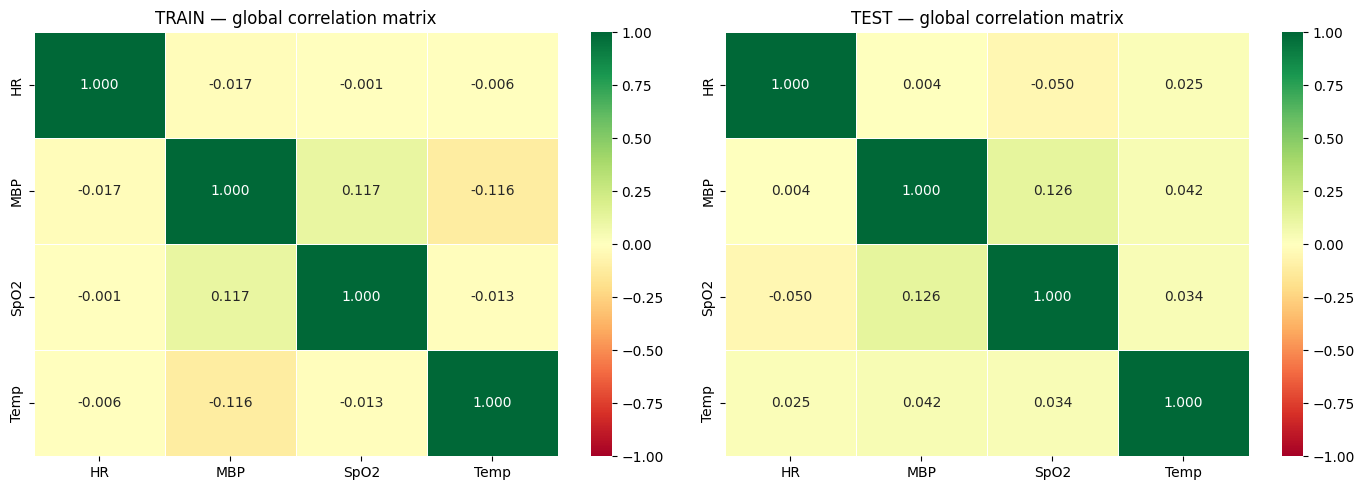

In [10]:
# This is critical for the embedding design:
# Normal physiology has stable cross-vital correlations.
# Anomalies break this structure — our embedding exploits this.

# Global correlation
print("=== Global cross-vital correlation (TRAIN) ===")
print(df_train[VITALS].corr().to_string())

print("\n=== Global cross-vital correlation (TEST) ===")
print(df_test[VITALS].corr().to_string())

# Per-patient correlation — does it vary a lot between patients?
print("\n=== Per-patient HR-MBP correlation (should be positive normally) ===")
per_patient_corr = df_train.groupby('case_id').apply(
    lambda g: g[['HR', 'MBP']].dropna().corr().iloc[0, 1]
).rename('hr_mbp_corr')
print(per_patient_corr.describe())
print(f"  Patients with negative HR-MBP corr : {(per_patient_corr < 0).sum()}")
print("  → Strong negatives may indicate anomalous periods dominating the case")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_train[VITALS].corr(), annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[0], vmin=-1, vmax=1, center=0,
            linewidths=0.5)
axes[0].set_title('TRAIN — global correlation matrix')

sns.heatmap(df_test[VITALS].corr(), annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[1], vmin=-1, vmax=1, center=0,
            linewidths=0.5)
axes[1].set_title('TEST — global correlation matrix')

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

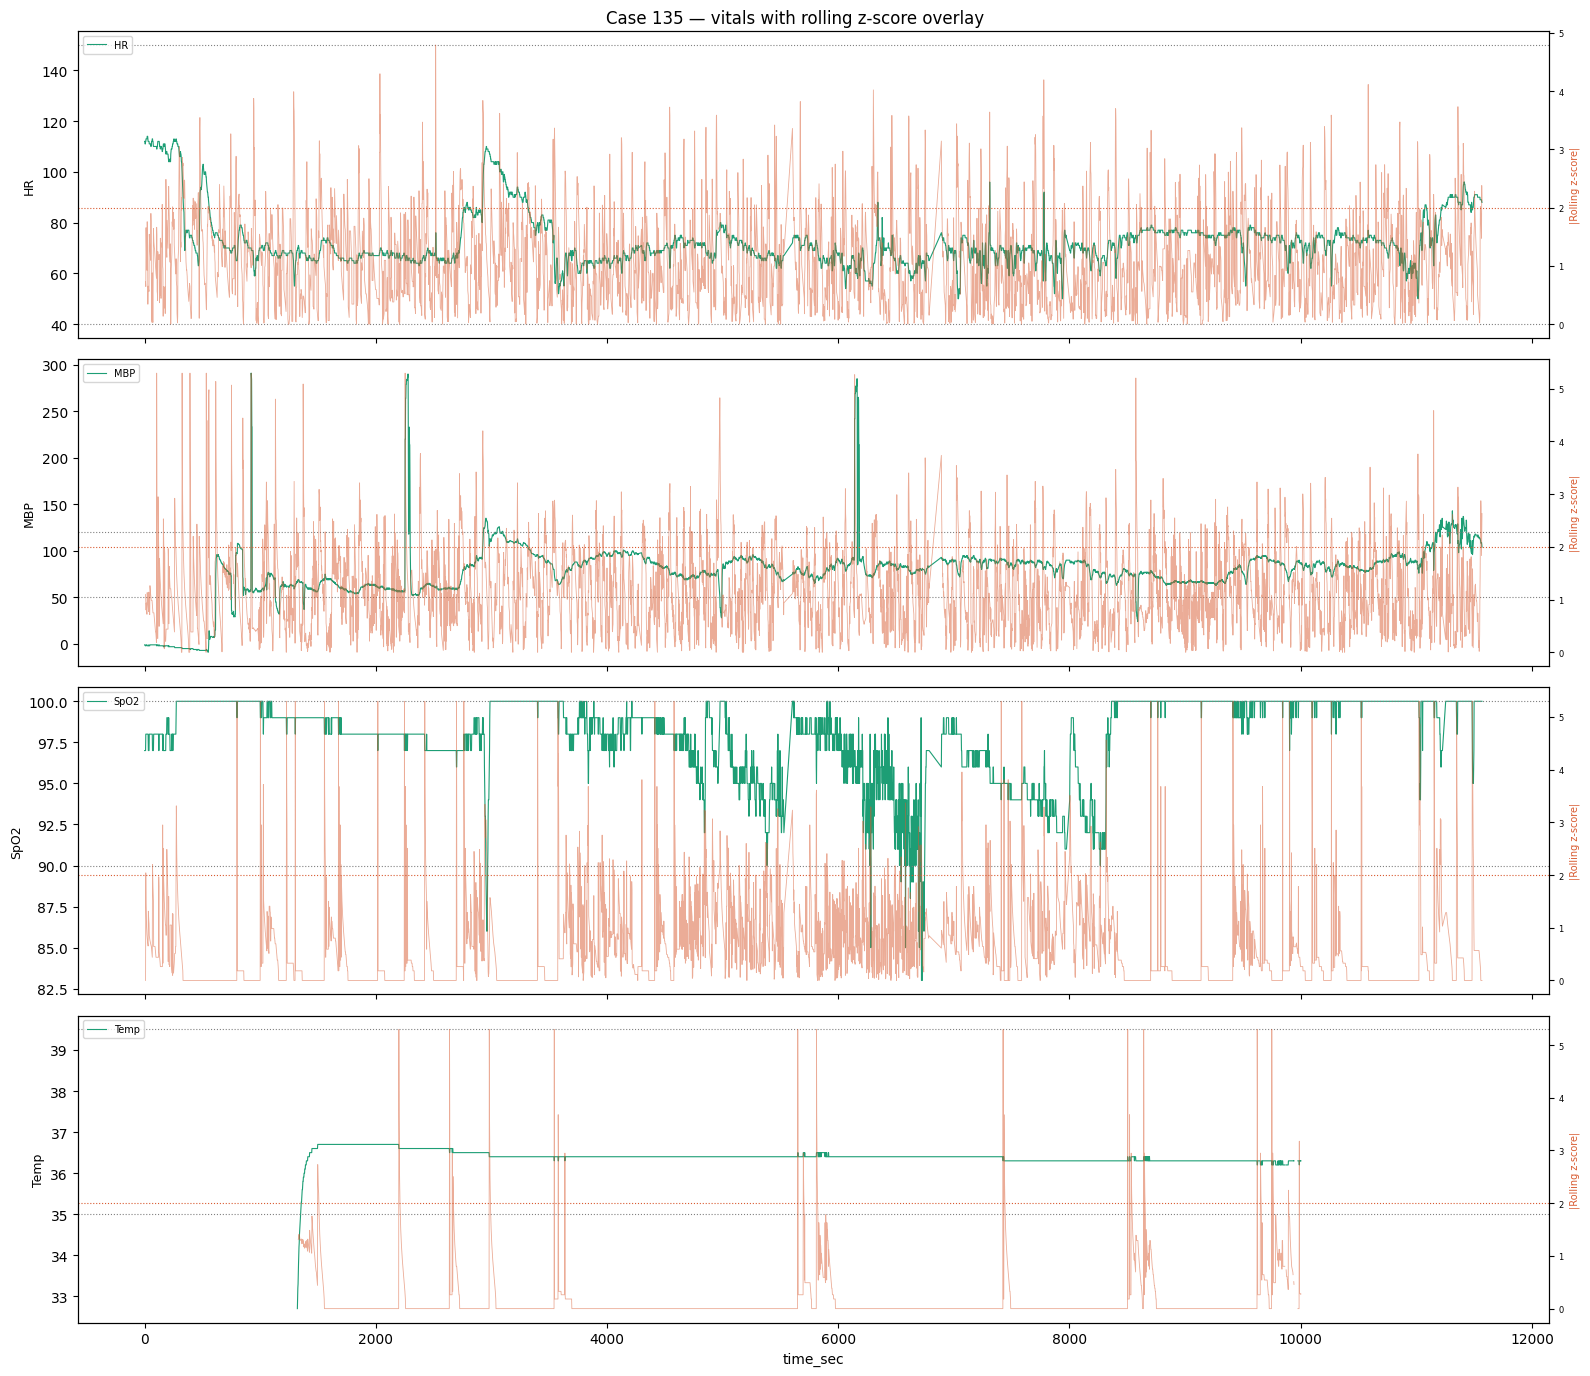

=== Autocorrelation at key lags (TRAIN, first case) ===
  (tells us how far in the past matters for predicting current state)
  HR     : lag1=0.993  lag5=0.944  lag15=0.875  lag30=0.783  lag60=0.673
  MBP    : lag1=0.970  lag5=0.846  lag15=0.694  lag30=0.580  lag60=0.541
  SpO2   : lag1=0.947  lag5=0.885  lag15=0.809  lag30=0.729  lag60=0.650
  Temp   : lag1=0.996  lag5=0.978  lag15=0.858  lag30=0.650  lag60=0.453


In [11]:
# Since we have no labels, we use rolling z-scores to find "unusual" periods
# This also tells us what window sizes to use in the model

# Work on one patient to get intuition
sample_case = sorted(df_train['case_id'].unique())[0]
sub = df_train[df_train['case_id'] == sample_case].sort_values('time_sec').copy()

WINDOWS = [10, 30, 60, 180]  # in timestamps (x2 for seconds)

fig, axes = plt.subplots(len(VITALS), 1, figsize=(16, 14), sharex=True)

for i, vital in enumerate(VITALS):
    ax = axes[i]
    series = sub[vital]
    ax.plot(sub['time_sec'], series, color=C_TRAIN, linewidth=0.8, label=vital)

    # Rolling z-score with 30-timestamp window
    roll_mean = series.rolling(30, min_periods=5).mean()
    roll_std  = series.rolling(30, min_periods=5).std()
    roll_z    = (series - roll_mean) / (roll_std + 1e-8)

    # Highlight where |z| > 2
    ax2 = ax.twinx()
    ax2.plot(sub['time_sec'], roll_z.abs(), color=C_ALERT,
             linewidth=0.6, alpha=0.5, label='|rolling z|')
    ax2.axhline(2, color=C_ALERT, linestyle=':', linewidth=0.8)
    ax2.set_ylabel('|Rolling z-score|', fontsize=7, color=C_ALERT)
    ax2.tick_params(labelsize=6)

    lo, hi = CLINICAL_NORMAL[vital]
    ax.axhline(lo, color='grey', linestyle=':', linewidth=0.8)
    ax.axhline(hi, color='grey', linestyle=':', linewidth=0.8)
    ax.set_ylabel(vital, fontsize=9)
    ax.legend(fontsize=7, loc='upper left')

axes[-1].set_xlabel('time_sec')
plt.suptitle(f'Case {sample_case} — vitals with rolling z-score overlay', fontsize=12)
plt.tight_layout()
plt.savefig('eda_rolling_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

# Understand what window captures anomaly structure
# Compare autocorrelation at different lags for each vital
print("=== Autocorrelation at key lags (TRAIN, first case) ===")
print("  (tells us how far in the past matters for predicting current state)")
for vital in VITALS:
    series = sub[vital].dropna()
    lags = [1, 5, 15, 30, 60]
    acfs = [series.autocorr(lag=l) for l in lags]
    acf_str = '  '.join([f'lag{l}={a:.3f}' for l, a in zip(lags, acfs)])
    print(f"  {vital:6s} : {acf_str}")

=== Clinical derived features — global statistics ===

  shock_index:
count   121830.0000
mean         0.4880
std          6.9047
min       -113.0000
25%          0.6882
50%          0.8171
75%          0.9538
max        107.0000

  spo2_deficit:
count   122347.0000
mean         0.3247
std          1.1329
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max         37.0000

  hr_deviation:
count   122347.0000
mean        26.8298
std         12.0710
min          0.0000
25%         19.0000
50%         28.0000
75%         35.0000
max        211.0000


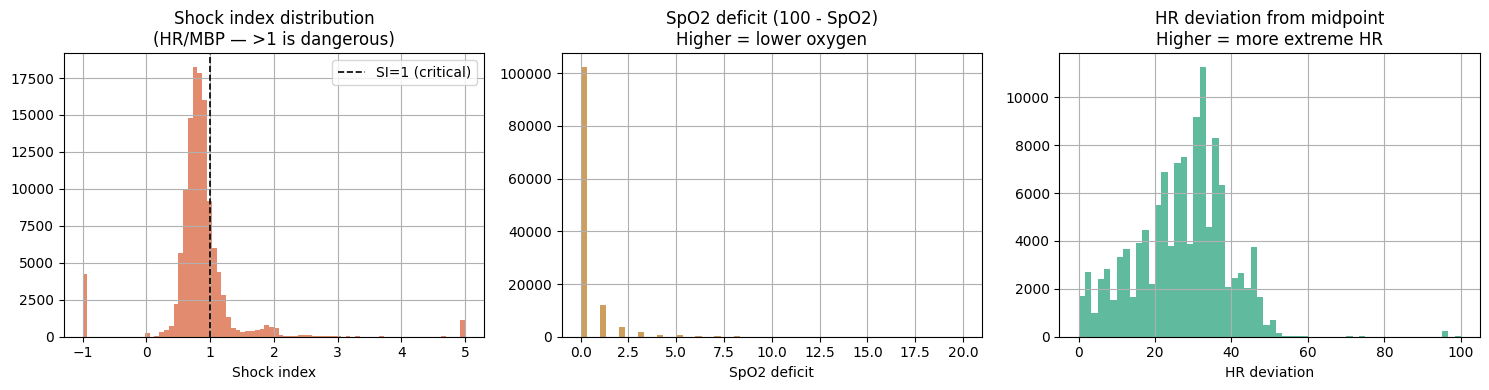

In [12]:
# Compute clinical indices that are known markers of physiological stress
# These validate our anomaly score design

df_train_feat = df_train.copy()
df_test_feat  = df_test.copy()

# Shock index: HR / MBP — elevated (>1) signals haemodynamic compromise
df_train_feat['shock_index'] = (
    df_train_feat['HR'] / df_train_feat['MBP'].replace(0, np.nan)
)

# SpO2 deviation from ceiling (100 = perfect, lower = worse)
df_train_feat['spo2_deficit'] = 100 - df_train_feat['SpO2']

# HR outside normal range — absolute deviation from [40,150] midpoint
HR_MID = (40 + 150) / 2
df_train_feat['hr_deviation'] = (df_train_feat['HR'] - HR_MID).abs()

print("=== Clinical derived features — global statistics ===")
for feat in ['shock_index', 'spo2_deficit', 'hr_deviation']:
    print(f"\n  {feat}:")
    print(df_train_feat[feat].describe().to_string())

# Distribution of shock index
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_train_feat['shock_index'].clip(-1, 5).hist(
    bins=80, ax=axes[0], color=C_ALERT, edgecolor='none', alpha=0.7)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='SI=1 (critical)')
axes[0].set_title('Shock index distribution\n(HR/MBP — >1 is dangerous)')
axes[0].set_xlabel('Shock index')
axes[0].legend()

df_train_feat['spo2_deficit'].clip(0, 20).hist(
    bins=60, ax=axes[1], color=C_ACCENT, edgecolor='none', alpha=0.7)
axes[1].set_title('SpO2 deficit (100 - SpO2)\nHigher = lower oxygen')
axes[1].set_xlabel('SpO2 deficit')

df_train_feat['hr_deviation'].clip(0, 100).hist(
    bins=60, ax=axes[2], color=C_TRAIN, edgecolor='none', alpha=0.7)
axes[2].set_title('HR deviation from midpoint\nHigher = more extreme HR')
axes[2].set_xlabel('HR deviation')

plt.tight_layout()
plt.savefig('eda_clinical_features.png', dpi=150, bbox_inches='tight')
plt.show()

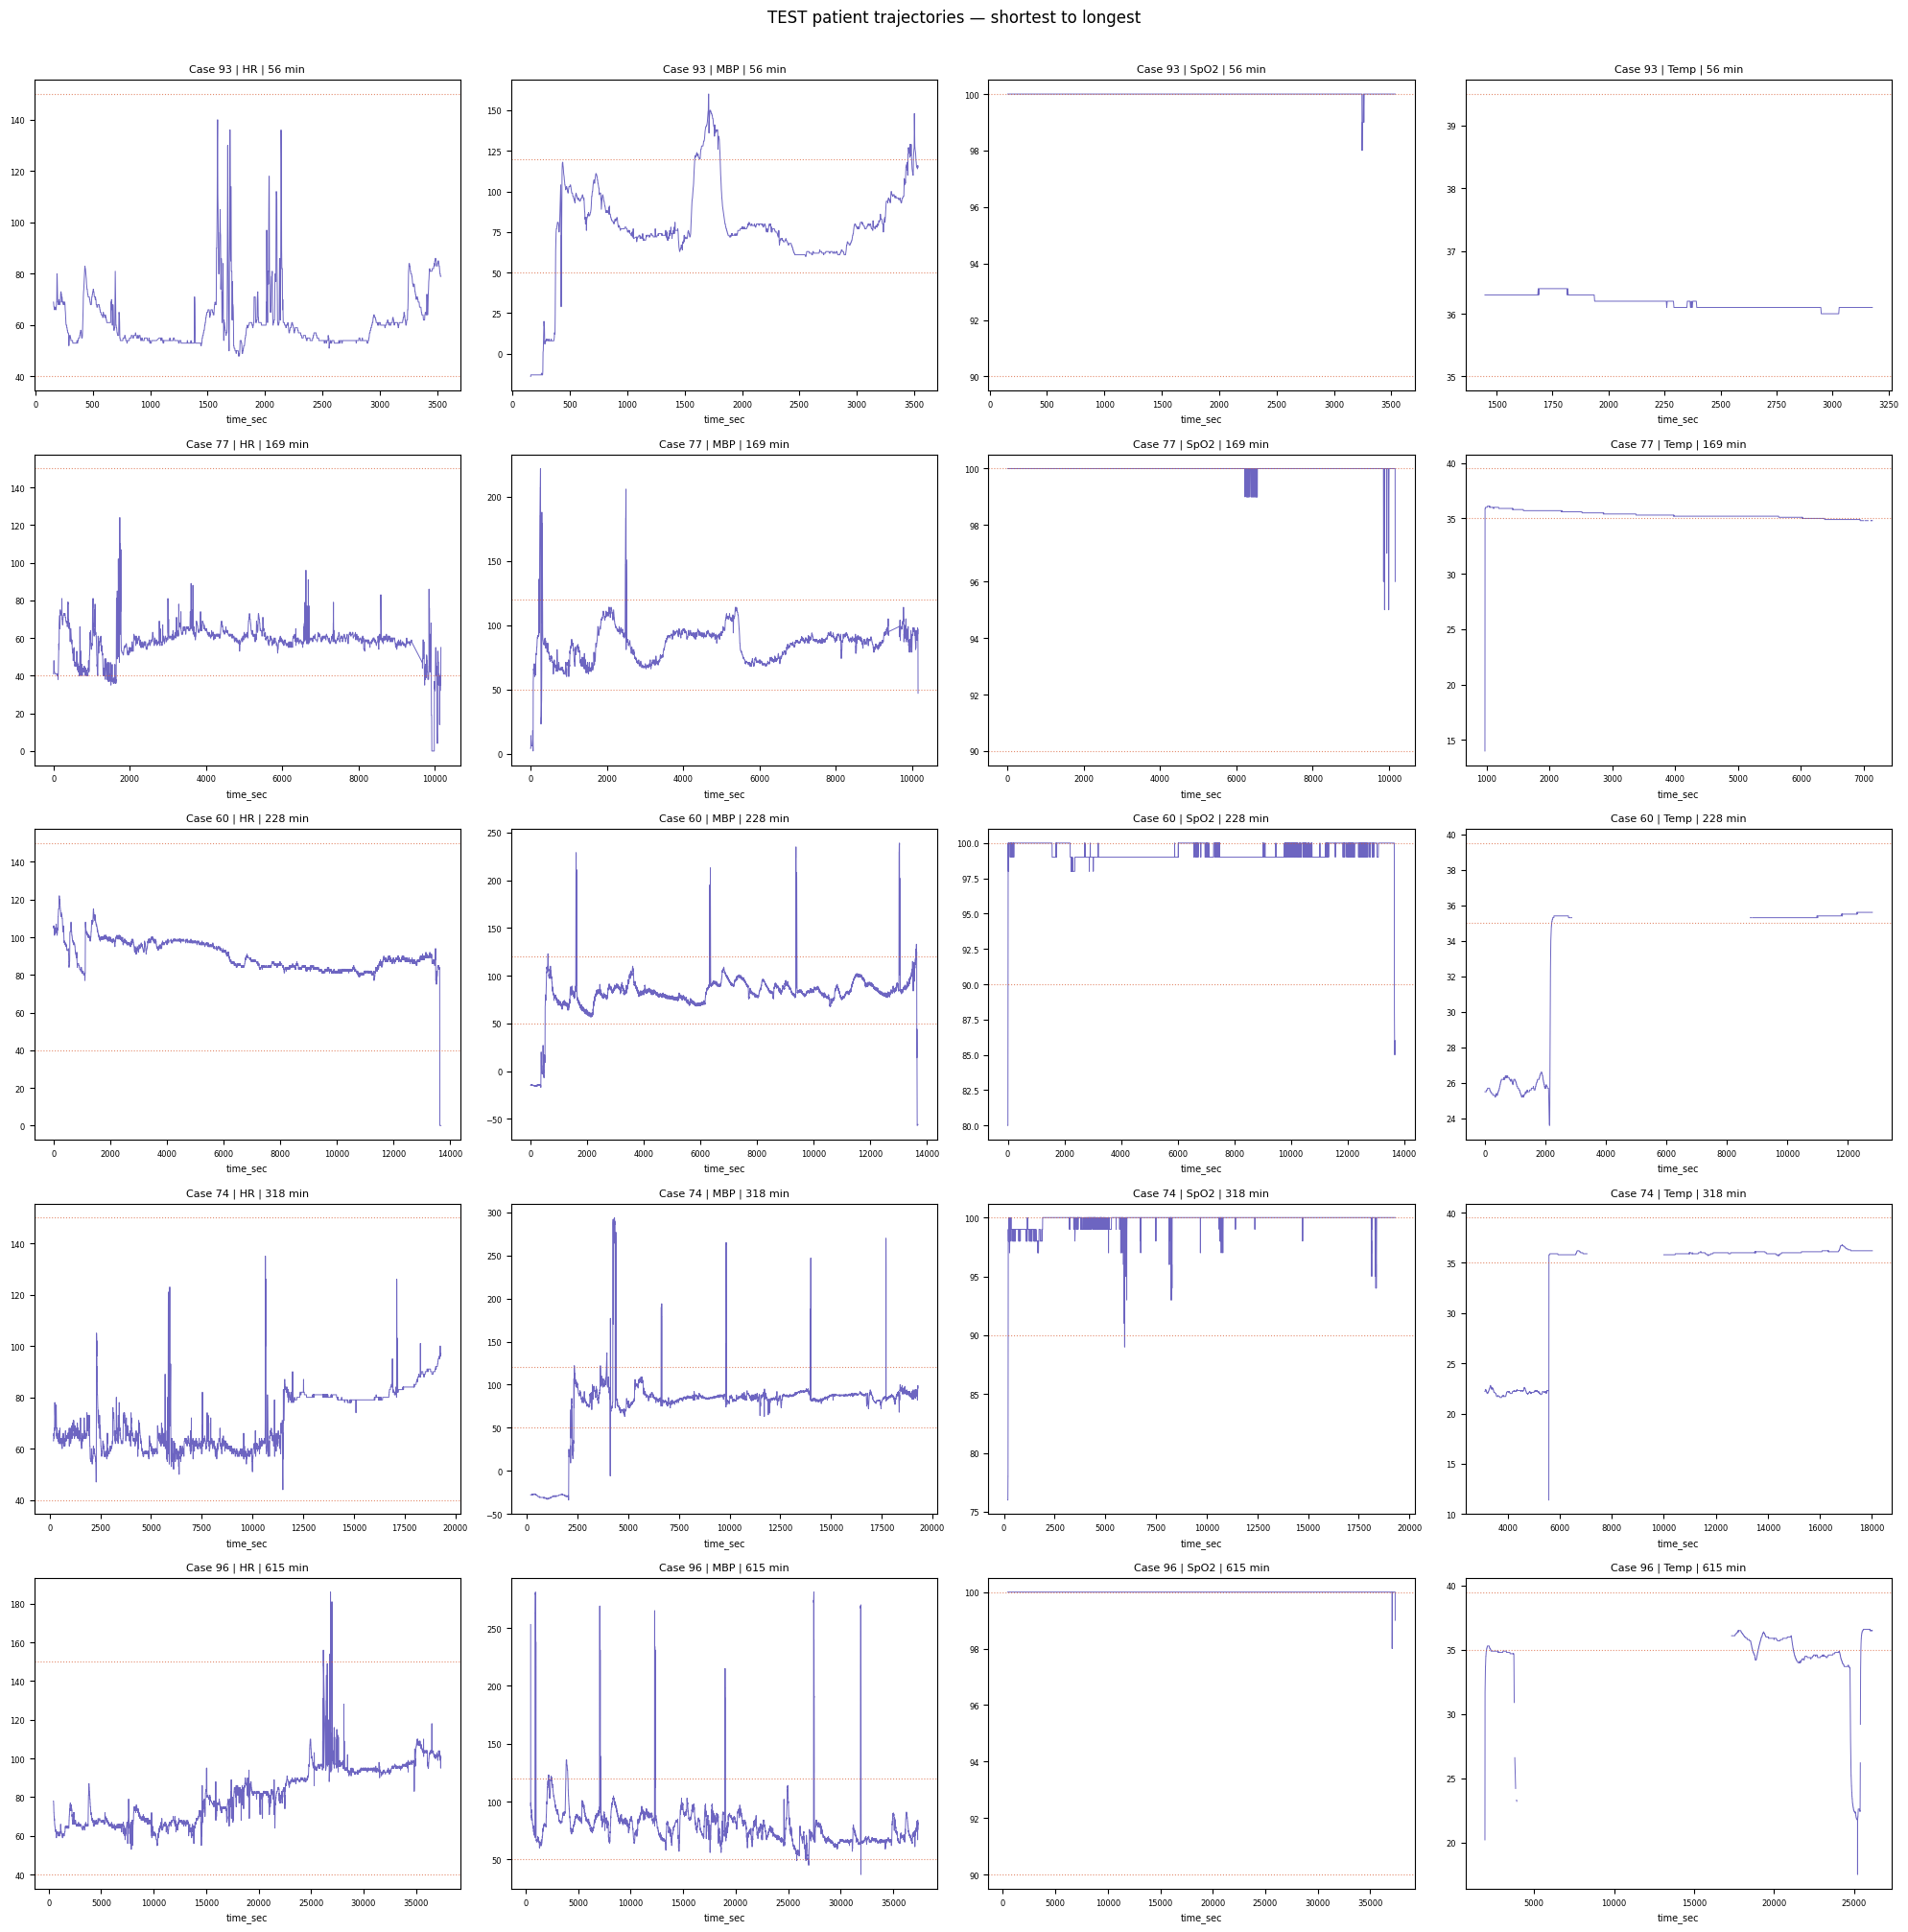

In [13]:
# Plot 6 patients — shortest, median, longest cases
# Gives intuition for what normal and abnormal periods look like

durations = test_case_stats.sort_values('duration_sec')
sample_ids = [
    durations.iloc[0]['case_id'],
    durations.iloc[len(durations)//4]['case_id'],
    durations.iloc[len(durations)//2]['case_id'],
    durations.iloc[3*len(durations)//4]['case_id'],
    durations.iloc[-1]['case_id'],
]

fig, axes = plt.subplots(len(sample_ids), 4, figsize=(20, 4*len(sample_ids)))

for row, case_id in enumerate(sample_ids):
    sub = df_test[df_test['case_id'] == case_id].sort_values('time_sec')
    dur = sub['time_sec'].max() - sub['time_sec'].min()

    for col, vital in enumerate(VITALS):
        ax = axes[row][col]
        ax.plot(sub['time_sec'], sub[vital],
                color=C_TEST, linewidth=0.7, alpha=0.85)
        lo, hi = CLINICAL_NORMAL[vital]
        ax.axhline(lo, color=C_ALERT, linestyle=':', linewidth=0.8, alpha=0.7)
        ax.axhline(hi, color=C_ALERT, linestyle=':', linewidth=0.8, alpha=0.7)
        ax.set_title(f'Case {case_id} | {vital} | {dur/60:.0f} min', fontsize=8)
        ax.set_xlabel('time_sec', fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('TEST patient trajectories — shortest to longest', fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig('eda_sample_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import json

# Fill these from the printed outputs above before saving
eda_decisions = {
    "dataset": {
        "train_shape"         : list(df_train.shape),
        "test_shape"          : list(df_test.shape),
        "train_n_cases"       : int(df_train['case_id'].nunique()),
        "test_n_cases"        : int(df_test['case_id'].nunique()),
        "case_id_overlap"     : bool(train_cases & test_cases),
        "task_type"           : "unsupervised_anomaly_detection",
    },
    "missingness": {
        "train_temp_missing_pct" : round(df_train['Temp'].isna().mean() * 100, 2),
        "test_temp_missing_pct"  : round(df_test['Temp'].isna().mean() * 100, 2),
        "temp_missing_structured": None,   # fill: True if decile pattern is uneven
        "add_temp_was_missing_flag": True,
        "imputation_strategy"    : "per_patient_rolling_median_window30_fallback_patient_median",
    },
    "artefact_thresholds": {
        # Refine lo values based on Cell 7 output
        "HR"  : {"lo": 1,    "hi": 250,  "action": "set_to_nan"},
        "MBP" : {"lo": None, "hi": 200,  "action": "set_to_nan"},  # fill lo after Cell 7
        "SpO2": {"lo": 50,   "hi": 100,  "action": "set_to_nan"},
        "Temp": {"lo": 25.0, "hi": 42.0, "action": "set_to_nan"},
    },
    "clinical_normal_ranges": CLINICAL_NORMAL,
    "normalisation": {
        "strategy"      : "per_patient_zscore",
        "baseline_window": "first_60_sec",
        "fallback"      : "per_patient_global_stats_if_baseline_too_short",
    },
    "temporal": {
        "time_step_sec"          : 2,          # confirm from Cell 3
        "recommended_window_sec" : None,       # fill from Cell 10 autocorrelation output
        "recommended_window_ts"  : None,       # window_sec / 2
    },
    "embedding_design": {
        "approach"          : "sinusoidal_quadratic_orthogonal",
        "cross_vital_features": ["shock_index", "spo2_deficit", "hr_deviation"],
        "notes"             : "fill after seeing cross-vital correlation output from Cell 9",
    },
}

with open('eda_decisions.json', 'w') as f:
    json.dump(eda_decisions, f, indent=2)

print("Saved: eda_decisions.json")
print()
print(json.dumps(eda_decisions, indent=2))

Saved: eda_decisions.json

{
  "dataset": {
    "train_shape": [
      122347,
      6
    ],
    "test_shape": [
      550583,
      6
    ],
    "train_n_cases": 20,
    "test_n_cases": 75,
    "case_id_overlap": false,
    "task_type": "unsupervised_anomaly_detection"
  },
  "missingness": {
    "train_temp_missing_pct": 57.18,
    "test_temp_missing_pct": 52.72,
    "temp_missing_structured": null,
    "add_temp_was_missing_flag": true,
    "imputation_strategy": "per_patient_rolling_median_window30_fallback_patient_median"
  },
  "artefact_thresholds": {
    "HR": {
      "lo": 1,
      "hi": 250,
      "action": "set_to_nan"
    },
    "MBP": {
      "lo": null,
      "hi": 200,
      "action": "set_to_nan"
    },
    "SpO2": {
      "lo": 50,
      "hi": 100,
      "action": "set_to_nan"
    },
    "Temp": {
      "lo": 25.0,
      "hi": 42.0,
      "action": "set_to_nan"
    }
  },
  "clinical_normal_ranges": {
    "HR": [
      40,
      150
    ],
    "MBP": [
      50,
     

In [64]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import copy
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. ROBUST PREPROCESSING (The Stable 0.94 Baseline)
# =====================================================================
def preprocess_vitals(df_path):
    print(f"Processing {df_path}...")
    df = pd.read_csv(df_path)
    df = df.sort_values(['case_id', 'time_sec']).reset_index(drop=True)
    
    df.loc[df['HR'] <= 0, 'HR'] = np.nan          
    df.loc[df['HR'] > 250, 'HR'] = np.nan         
    df.loc[df['MBP'] < -30, 'MBP'] = np.nan       
    df.loc[df['MBP'] > 200, 'MBP'] = np.nan       
    df.loc[df['SpO2'] < 50, 'SpO2'] = np.nan      
    df.loc[(df['Temp'] < 25) | (df['Temp'] > 42), 'Temp'] = np.nan 
    
    df['Temp_missing'] = df['Temp'].isna().astype(int)
    
    # Pure Mean/Std Normalization
    for vital in ['HR', 'MBP', 'SpO2', 'Temp']:
        z_col = f'{vital}_z'
        df[z_col] = np.nan
        for cid, grp in df.groupby('case_id'):
            baseline = grp.head(30)[vital].dropna() 
            mu = baseline.mean() if len(baseline) > 5 else grp[vital].median()
            sigma = baseline.std() if len(baseline) > 5 else grp[vital].std()
            df.loc[grp.index, z_col] = (df.loc[grp.index, vital] - mu) / max(sigma, 0.01)

    for cid, grp in df.groupby('case_id'):
        idx = grp.index
        df.loc[idx, 'Temp_z'] = df.loc[idx, 'Temp_z'].ffill(limit=10).bfill(limit=10).fillna(0.0) 
        for v in ['HR_z', 'MBP_z', 'SpO2_z']:
            df.loc[idx, v] = df.loc[idx, v].ffill().bfill().fillna(0.0)
            
    df['shock_index'] = (df['HR'] / df['MBP'].replace(0, np.nan).fillna(1.0)).clip(0, 5)
    df['spo2_deficit'] = (100 - df['SpO2'].fillna(100)).clip(0, 50)
    df['hr_deviation'] = (df['HR'].fillna(80) - 95).abs().clip(0, 100)
    
    for vital in ['HR_z', 'MBP_z', 'SpO2_z', 'Temp_z']:
        df[f'{vital}_roll_std'] = df.groupby('case_id')[vital].transform(lambda x: x.rolling(30, min_periods=5).std().fillna(0))
        df[f'{vital}_diff1'] = df.groupby('case_id')[vital].transform(lambda x: x.diff().fillna(0))
    
    df.fillna(0.0, inplace=True)

    feat_cols = ['Temp_missing', 'shock_index', 'spo2_deficit', 'hr_deviation'] + \
                [f'{v}_roll_std' for v in ['HR_z', 'MBP_z', 'SpO2_z', 'Temp_z']] + \
                [f'{v}_diff1' for v in ['HR_z', 'MBP_z', 'SpO2_z', 'Temp_z']]
    
    for col in feat_cols:
        df[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-5)
        
    return df

train_df = preprocess_vitals('train_vitals.csv')
test_df = preprocess_vitals('test_vitals.csv')

# =====================================================================
# 2. INDUCTIVE PATIENT-WISE SPLIT
# =====================================================================
print("\nCreating Strict Inductive Split...")
unique_cases = train_df['case_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_cases)

split_idx = int(len(unique_cases) * 0.8) 
train_cases = unique_cases[:split_idx]
val_cases = unique_cases[split_idx:]

train_split_df = train_df[train_df['case_id'].isin(train_cases)].copy()
val_split_df = train_df[train_df['case_id'].isin(val_cases)].copy()

class ICUWindowDataset(Dataset):
    def __init__(self, df, window_size=30): 
        self.windows, self.features, self.indices = [], [], []
        vital_cols = ['HR_z', 'MBP_z', 'SpO2_z', 'Temp_z']
        feat_cols = ['Temp_missing', 'shock_index', 'spo2_deficit', 'hr_deviation'] + \
                    [f'{v}_roll_std' for v in vital_cols] + \
                    [f'{v}_diff1' for v in vital_cols]
        
        for cid, grp in df.groupby('case_id'):
            vitals_arr = grp[vital_cols].values
            feats_arr = grp[feat_cols].values
            for i in range(len(grp)):
                start_idx = max(0, i - window_size + 1)
                window = vitals_arr[start_idx:i+1]
                if len(window) < window_size:
                    pad = np.repeat(window[0:1], window_size - len(window), axis=0)
                    window = np.vstack([pad, window])
                self.windows.append(window)
                self.features.append(feats_arr[i])
                self.indices.append(grp.index[i])
                    
    def __len__(self): return len(self.windows)
    def __getitem__(self, idx):
        return torch.tensor(self.windows[idx], dtype=torch.float32), \
               torch.tensor(self.features[idx], dtype=torch.float32), \
               self.indices[idx]

train_ds = ICUWindowDataset(train_split_df, window_size=30)
val_ds = ICUWindowDataset(val_split_df, window_size=30)
test_ds = ICUWindowDataset(test_df, window_size=30)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True) 
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

# =====================================================================
# 3. THE GOLDEN ARCHITECTURE (Linear SQOB)
# =====================================================================
class SQOBEncoder(nn.Module):
    def __init__(self, window=30, d_per_vital=64, omega0=0.1, alpha=0.05):
        super().__init__()
        k = torch.arange(d_per_vital // 2).float()
        freqs = omega0 * (1 + alpha * k ** 2)  
        t = torch.linspace(0, 1, window).float()  
        
        sins = torch.sin(freqs.unsqueeze(0) * t.unsqueeze(1))
        coss = torch.cos(freqs.unsqueeze(0) * t.unsqueeze(1))
        basis = torch.cat([sins, coss], dim=1)
        
        self.register_buffer('basis', basis.float().contiguous()) 
        self.proj = nn.Linear(d_per_vital, d_per_vital, bias=False)

    def forward(self, x):
        z_list = [self.proj(torch.matmul(x[:, :, v].contiguous(), self.basis)) for v in range(4)]
        return torch.cat(z_list, dim=-1)

class SQOBAutoencoder(nn.Module):
    def __init__(self, window=30, d=64, n_feat=12):
        super().__init__()
        self.enc = SQOBEncoder(window=window, d_per_vital=d)
        self.dec = nn.Sequential(
            nn.Linear(4*d + n_feat, 256),
            nn.GELU(),
            nn.Dropout(0.2), 
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, window * 4) 
        )

    def forward(self, window, features):
        z = self.enc(window)
        combined = torch.cat([z, features], dim=-1)
        reconstruction = self.dec(combined)
        return reconstruction.view(window.shape[0], window.shape[1], 4), z

def unsupervised_sqob_loss(reconstruction, target_window, model, lam1=1e-4):
    l1_loss = F.smooth_l1_loss(reconstruction, target_window, reduction='none')
    
    # Pure Linear Weighting
    weights = torch.linspace(0.1, 1.0, target_window.shape[1]).to(target_window.device)
    weighted_loss = (l1_loss.mean(dim=-1) * weights).mean()
    
    W = model.enc.proj.weight
    orth_loss = (torch.matmul(W, W.T) - torch.eye(W.shape[0], device=W.device)).pow(2).mean() 
    
    return weighted_loss + (lam1 * orth_loss), weighted_loss

# =====================================================================
# 4. STABLE TRAINING LOOP
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sqob_model = SQOBAutoencoder(window=30, d=64, n_feat=12).to(device)

epochs = 60
optimizer = optim.AdamW(sqob_model.parameters(), lr=2e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

def train_sqob_ae(epochs=60, patience=20): 
    best_val_loss = float('inf')
    best_model_weights = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        sqob_model.train()
        train_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for windows, features, _ in loop:
            windows, features = windows.to(device), features.to(device)
            aug_windows = windows + (torch.randn_like(windows) * 0.05)
            
            optimizer.zero_grad()
            reconstruction, _ = sqob_model(aug_windows, features)
            loss, _ = unsupervised_sqob_loss(reconstruction, windows, sqob_model) 
            loss.backward()
            torch.nn.utils.clip_grad_norm_(sqob_model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            
        scheduler.step() 
            
        sqob_model.eval()
        val_loss = 0
        with torch.no_grad():
            for val_win, val_feat, _ in val_loader:
                recon, _ = sqob_model(val_win.to(device), val_feat.to(device))
                loss, _ = unsupervised_sqob_loss(recon, val_win.to(device), sqob_model) 
                val_loss += loss.item()
                
        avg_val = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_weights = copy.deepcopy(sqob_model.state_dict())
            epochs_no_improve = 0
            print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | Train Loss: {train_loss/len(train_loader):.4f} -> NEW BEST VAL: {avg_val:.4f}")
        else:
            epochs_no_improve += 1
            print(f"Epoch {epoch+1} | LR: {current_lr:.6f} | Train Loss: {train_loss/len(train_loader):.4f} -> Val Loss: {avg_val:.4f}")
            if epochs_no_improve >= patience:
                print(f"\n[Early Stopping] Triggered to prevent overfitting.")
                break

    print(f"\nLoading mathematically optimal weights (Val Loss: {best_val_loss:.4f})...")
    sqob_model.load_state_dict(best_model_weights)

train_sqob_ae(epochs=epochs, patience=20)

# =====================================================================
# 5. SUPER-ENSEMBLE & KNOWLEDGE DISTILLATION
# =====================================================================
def get_sqob_outputs_with_tta(loader, n_augmentations=3):
    sqob_model.eval()
    preds_dict, embeds_list = {}, []
    
    with torch.no_grad():
        for windows, features, idxs in loader:
            windows, features = windows.to(device), features.to(device)
            
            recon, z = sqob_model(windows, features)
            errors = F.smooth_l1_loss(recon[:, -1, :], windows[:, -1, :], reduction='none').mean(dim=-1)
            
            for _ in range(n_augmentations):
                noisy_windows = windows + (torch.randn_like(windows) * 0.01)
                recon_aug, _ = sqob_model(noisy_windows, features)
                aug_errors = F.smooth_l1_loss(recon_aug[:, -1, :], windows[:, -1, :], reduction='none').mean(dim=-1)
                errors += aug_errors
                
            errors = errors / (n_augmentations + 1)
            scores = errors.cpu().numpy().flatten()
            
            for score, idx in zip(scores, idxs.numpy()):
                preds_dict[idx] = score
            embeds_list.append(z.cpu().numpy())
            
    return preds_dict, np.vstack(embeds_list)

print("\nExecuting Test-Time Augmentation (TTA) Inference...")
full_train_loader = DataLoader(ICUWindowDataset(train_df, window_size=30), batch_size=512, shuffle=False)
train_sqob_preds, train_embeds = get_sqob_outputs_with_tta(full_train_loader)
test_sqob_preds, test_embeds = get_sqob_outputs_with_tta(test_loader)

print("Training Deep Isolation Forest...")
iso_forest = IsolationForest(n_estimators=300, max_samples=512, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(train_embeds) 

train_df['sqob_score'] = train_df.index.map(train_sqob_preds).fillna(0)
train_df['if_score'] = -iso_forest.decision_function(train_embeds)
test_df['sqob_score'] = test_df.index.map(test_sqob_preds).fillna(0)
test_df['if_score'] = -iso_forest.decision_function(test_embeds)

print("Calculating Scale-Invariant Rank Percentiles...")
train_df['sqob_rank'] = train_df['sqob_score'].rank(pct=True)
train_df['if_rank'] = train_df['if_score'].rank(pct=True)
train_df['base_ensemble_rank'] = (0.75 * train_df['sqob_rank']) + (0.25 * train_df['if_rank'])

test_df['sqob_rank'] = test_df['sqob_score'].rank(pct=True)
test_df['if_rank'] = test_df['if_score'].rank(pct=True)
test_df['base_ensemble_rank'] = (0.75 * test_df['sqob_rank']) + (0.25 * test_df['if_rank'])

print("Distilling Manifold into Supervised XGBoost...")
xgb_feat_cols = ['Temp_missing', 'shock_index', 'spo2_deficit', 'hr_deviation',
                 'HR_z_roll_std', 'MBP_z_roll_std', 'SpO2_z_roll_std', 'Temp_z_roll_std',
                 'HR_z_diff1', 'MBP_z_diff1', 'SpO2_z_diff1', 'Temp_z_diff1']

train_df['pseudo_label'] = np.nan
train_df.loc[train_df['base_ensemble_rank'] >= 0.95, 'pseudo_label'] = 1 
train_df.loc[train_df['base_ensemble_rank'] <= 0.60, 'pseudo_label'] = 0 

pseudo_train = train_df.dropna(subset=['pseudo_label'])
X_pseudo = pseudo_train[xgb_feat_cols].values
y_pseudo = pseudo_train['pseudo_label'].values

scale_pos_weight = len(y_pseudo[y_pseudo == 0]) / max(1, len(y_pseudo[y_pseudo == 1]))

xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=4, 
    learning_rate=0.05, 
    scale_pos_weight=scale_pos_weight, 
    objective='binary:logistic',
    eval_metric='aucpr', 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_pseudo, y_pseudo)

test_df['xgb_score'] = xgb_model.predict_proba(test_df[xgb_feat_cols].values)[:, 1]
test_df['xgb_rank'] = test_df['xgb_score'].rank(pct=True)

print("Finalizing Super-Ensemble and Smoothing...")
test_df['raw_anomaly_score'] = (0.50 * test_df['sqob_rank']) + (0.30 * test_df['xgb_rank']) + (0.20 * test_df['if_rank'])

test_df['anomaly_score'] = test_df.groupby('case_id')['raw_anomaly_score'].transform(
    lambda x: x.rolling(window=5, win_type='gaussian', center=True, min_periods=1).mean(std=1.5)
)

submission_df = test_df[['case_id', 'time_sec', 'anomaly_score']].copy()
submission_df.to_csv('final_submission.csv', index=False)
print("SUCCESS: Pipeline complete. Export final_submission.csv.")

Processing train_vitals.csv...
Processing test_vitals.csv...

Creating Strict Inductive Split...


Epoch 1/60 [Train]: 100%|██████████| 377/377 [00:02<00:00, 125.67it/s]


Epoch 1 | LR: 0.000200 | Train Loss: 72.0258 -> NEW BEST VAL: 3.5213


Epoch 2/60 [Train]: 100%|██████████| 377/377 [00:03<00:00, 111.83it/s]


Epoch 2 | LR: 0.000199 | Train Loss: 35.9212 -> NEW BEST VAL: 3.3061


...

Epoch 58 | LR: 0.000002 | Train Loss: 12.8903 -> NEW BEST VAL: 0.8040


Epoch 59/60 [Train]: 100%|██████████| 377/377 [00:03<00:00, 125.32it/s]


Epoch 59 | LR: 0.000001 | Train Loss: 12.8197 -> Val Loss: 0.8091


Epoch 60/60 [Train]: 100%|██████████| 377/377 [00:03<00:00, 124.49it/s]


Epoch 60 | LR: 0.000001 | Train Loss: 12.9388 -> Val Loss: 0.8075

Loading mathematically optimal weights (Val Loss: 0.8040)...

Executing Test-Time Augmentation (TTA) Inference...
Training Deep Isolation Forest...
Calculating Scale-Invariant Rank Percentiles...
Distilling Manifold into Supervised XGBoost...
Finalizing Super-Ensemble and Smoothing...
SUCCESS: Pipeline complete. Export final_submission.csv.
